# Tugas Naive Bayes: Klasifikasi Minat Membeli Produk Secara Online

**Metode:** Naive Bayes Classifier (Perhitungan Manual + Implementasi Python)

**Tujuan:** Menentukan apakah seorang pelanggan termasuk **Tertarik** atau **Tidak Tertarik** membeli suatu produk berdasarkan fitur Harga, Diskon, dan Ulasan.

---

## Dataset Latih

| No | Harga  | Diskon    | Ulasan | Hasil           |
|----|--------|-----------|--------|-----------------|
| 1  | Murah  | Ada       | Baik   | Tertarik        |
| 2  | Murah  | Ada       | Baik   | Tertarik        |
| 3  | Sedang | Ada       | Baik   | Tertarik        |
| 4  | Mahal  | Tidak Ada | Buruk  | Tidak Tertarik  |
| 5  | Mahal  | Tidak Ada | Buruk  | Tidak Tertarik  |
| 6  | Sedang | Ada       | Baik   | Tertarik        |
| 7  | Sedang | Tidak Ada | Baik   | Tertarik        |
| 8  | Mahal  | Ada       | Buruk  | Tidak Tertarik  |

**Data baru yang ingin diprediksi:**
- Harga = **Sedang**
- Diskon = **Ada**
- Ulasan = **Baik**

---
## BAGIAN 1: Perhitungan Manual Naive Bayes

### Langkah 1 — Menentukan Kelas
Terdapat **2 kelas**:
- Kelas A: **Tertarik**
- Kelas B: **Tidak Tertarik**

---

### Langkah 2 — Menghitung Prior Probability

Dari 8 data latih:
- Jumlah **Tertarik** = 5 (nomor 1, 2, 3, 6, 7)
- Jumlah **Tidak Tertarik** = 3 (nomor 4, 5, 8)

$$P(Tertarik) = \frac{5}{8} = 0{,}625$$

$$P(Tidak\ Tertarik) = \frac{3}{8} = 0{,}375$$

---

### Langkah 3A — Likelihood untuk Kelas **Tertarik** (total 5 data)

| Fitur | Frekuensi | Likelihood |
|---|---|---|
| P(Harga=Sedang \| Tertarik) | 3 dari 5 (no. 3, 6, 7) | **3/5 = 0,6** |
| P(Diskon=Ada \| Tertarik) | 4 dari 5 (no. 1, 2, 3, 6) | **4/5 = 0,8** |
| P(Ulasan=Baik \| Tertarik) | 5 dari 5 | **5/5 = 1,0** |

---

### Langkah 3B — Likelihood untuk Kelas **Tidak Tertarik** (total 3 data)

| Fitur | Frekuensi | Likelihood |
|---|---|---|
| P(Harga=Sedang \| Tidak Tertarik) | 0 dari 3 | **0/3 = 0** → *pakai Laplace: 1/6 ≈ 0,167* |
| P(Diskon=Ada \| Tidak Tertarik) | 1 dari 3 (no. 8) | **1/3 ≈ 0,333** |
| P(Ulasan=Baik \| Tidak Tertarik) | 0 dari 3 | **0/3 = 0** → *pakai Laplace: 1/5 = 0,2* |

> **Catatan Zero Probability:** Fitur Harga=Sedang dan Ulasan=Baik tidak pernah muncul di kelas Tidak Tertarik, sehingga probabilitasnya = 0. Ini akan membuat hasil perkalian posterior = 0. Untuk mengatasi ini digunakan **Laplace Smoothing** (menambah 1 pada frekuensi, dan menambah jumlah nilai unik fitur pada pembagi).

---

### Langkah 4 — Menghitung Posterior (Tanpa Normalisasi)

**Posterior Tertarik:**
$$P(Tertarik\ |\ data) \propto 0{,}625 \times 0{,}6 \times 0{,}8 \times 1{,}0 = \mathbf{0{,}30}$$

**Posterior Tidak Tertarik (dengan Laplace Smoothing):**
$$P(Tidak\ Tertarik\ |\ data) \propto 0{,}375 \times 0{,}167 \times 0{,}333 \times 0{,}2 \approx \mathbf{0{,}0042}$$

---

### Langkah 5 — Keputusan Klasifikasi

| Kelas | Nilai Posterior |
|---|---|
| Tertarik | **0,30** |
| Tidak Tertarik | 0,0042 |

**Karena 0,30 > 0,0042 → Pelanggan diprediksi: TERTARIK**

---

### 📝 Alasan Hasil Klasifikasi
Pelanggan dengan profil **Harga=Sedang, Diskon=Ada, Ulasan=Baik** diprediksi **Tertarik** karena:
1. Kombinasi fitur tersebut sangat dominan muncul di kelompok **Tertarik** pada data latih.
2. Semua mahasiswa yang lulus memiliki Ulasan=Baik (likelihood = 1,0), sehingga bobot kelas Tertarik sangat tinggi.
3. Nilai posterior Tertarik (0,30) jauh lebih besar dibanding Tidak Tertarik (0,0042).

## BAGIAN 2: Implementasi Python dengan Scikit-Learn

In [1]:
# ============================================================
# Import Library
# ============================================================
import pandas as pd
import numpy as np
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Library berhasil diimport!")

✅ Library berhasil diimport!


In [2]:
# ============================================================
# Dataset Latih
# ============================================================
data = {
    'Harga':  ['Murah', 'Murah', 'Sedang', 'Mahal', 'Mahal', 'Sedang', 'Sedang', 'Mahal'],
    'Diskon': ['Ada', 'Ada', 'Ada', 'Tidak Ada', 'Tidak Ada', 'Ada', 'Tidak Ada', 'Ada'],
    'Ulasan': ['Baik', 'Baik', 'Baik', 'Buruk', 'Buruk', 'Baik', 'Baik', 'Buruk'],
    'Hasil':  ['Tertarik', 'Tertarik', 'Tertarik', 'Tidak Tertarik',
               'Tidak Tertarik', 'Tertarik', 'Tertarik', 'Tidak Tertarik']
}

df = pd.DataFrame(data)
print("📋 Dataset Latih:")
print(df.to_string(index=True))
print(f"\nTotal data: {len(df)}")
print(f"Distribusi kelas:\n{df['Hasil'].value_counts()}")

📋 Dataset Latih:
    Harga     Diskon Ulasan           Hasil
0   Murah        Ada   Baik        Tertarik
1   Murah        Ada   Baik        Tertarik
2  Sedang        Ada   Baik        Tertarik
3   Mahal  Tidak Ada  Buruk  Tidak Tertarik
4   Mahal  Tidak Ada  Buruk  Tidak Tertarik
5  Sedang        Ada   Baik        Tertarik
6  Sedang  Tidak Ada   Baik        Tertarik
7   Mahal        Ada  Buruk  Tidak Tertarik

Total data: 8
Distribusi kelas:
Hasil
Tertarik          5
Tidak Tertarik    3
Name: count, dtype: int64


In [3]:
# ============================================================
# Encoding Fitur Kategorikal
# ============================================================
le_harga  = LabelEncoder()
le_diskon = LabelEncoder()
le_ulasan = LabelEncoder()
le_hasil  = LabelEncoder()

df_encoded = df.copy()
df_encoded['Harga']  = le_harga.fit_transform(df['Harga'])
df_encoded['Diskon'] = le_diskon.fit_transform(df['Diskon'])
df_encoded['Ulasan'] = le_ulasan.fit_transform(df['Ulasan'])
df_encoded['Hasil']  = le_hasil.fit_transform(df['Hasil'])

print("🔢 Dataset setelah encoding:")
print(df_encoded)
print("\nMapping Harga :", dict(zip(le_harga.classes_, le_harga.transform(le_harga.classes_))))
print("Mapping Diskon:", dict(zip(le_diskon.classes_, le_diskon.transform(le_diskon.classes_))))
print("Mapping Ulasan:", dict(zip(le_ulasan.classes_, le_ulasan.transform(le_ulasan.classes_))))
print("Mapping Hasil :", dict(zip(le_hasil.classes_, le_hasil.transform(le_hasil.classes_))))

🔢 Dataset setelah encoding:
   Harga  Diskon  Ulasan  Hasil
0      1       0       0      0
1      1       0       0      0
2      2       0       0      0
3      0       1       1      1
4      0       1       1      1
5      2       0       0      0
6      2       1       0      0
7      0       0       1      1

Mapping Harga : {'Mahal': 0, 'Murah': 1, 'Sedang': 2}
Mapping Diskon: {'Ada': 0, 'Tidak Ada': 1}
Mapping Ulasan: {'Baik': 0, 'Buruk': 1}
Mapping Hasil : {'Tertarik': 0, 'Tidak Tertarik': 1}


In [4]:
# ============================================================
# Training Model Naive Bayes
# ============================================================
X = df_encoded[['Harga', 'Diskon', 'Ulasan']].values
y = df_encoded['Hasil'].values

# Menggunakan CategoricalNB yang sesuai untuk fitur kategorikal
# alpha=1.0 = Laplace Smoothing aktif
model = CategoricalNB(alpha=1.0)
model.fit(X, y)

print("✅ Model Naive Bayes berhasil dilatih!")
print(f"Kelas yang dikenali model: {le_hasil.classes_}")

✅ Model Naive Bayes berhasil dilatih!
Kelas yang dikenali model: ['Tertarik' 'Tidak Tertarik']


In [5]:
# ============================================================
# Prediksi Data Baru
# ============================================================
# Data baru: Harga=Sedang, Diskon=Ada, Ulasan=Baik
data_baru_raw = {
    'Harga':  'Sedang',
    'Diskon': 'Ada',
    'Ulasan': 'Baik'
}

# Encode data baru
harga_enc  = le_harga.transform([data_baru_raw['Harga']])[0]
diskon_enc = le_diskon.transform([data_baru_raw['Diskon']])[0]
ulasan_enc = le_ulasan.transform([data_baru_raw['Ulasan']])[0]

data_baru = np.array([[harga_enc, diskon_enc, ulasan_enc]])

# Prediksi kelas
prediksi_enc  = model.predict(data_baru)
prediksi_label = le_hasil.inverse_transform(prediksi_enc)[0]

# Probabilitas tiap kelas
proba = model.predict_proba(data_baru)[0]

print("=" * 50)
print("📌 DATA BARU YANG DIPREDIKSI:")
for k, v in data_baru_raw.items():
    print(f"   {k} = {v}")
print("=" * 50)
print("\n📊 PROBABILITAS TIAP KELAS:")
for kelas, prob in zip(le_hasil.classes_, proba):
    bar = '█' * int(prob * 40)
    print(f"   {kelas:<20}: {prob:.4f}  {bar}")
print("=" * 50)
print(f"\n🎯 HASIL PREDIKSI: {prediksi_label.upper()}")
print("=" * 50)

📌 DATA BARU YANG DIPREDIKSI:
   Harga = Sedang
   Diskon = Ada
   Ulasan = Baik

📊 PROBABILITAS TIAP KELAS:
   Tertarik            : 0.9745  ██████████████████████████████████████
   Tidak Tertarik      : 0.0255  █

🎯 HASIL PREDIKSI: TERTARIK


In [6]:
# ============================================================
# Evaluasi Model (menggunakan data latih sebagai referensi)
# Catatan: Pada dataset kecil, evaluasi ideal pakai cross-validation
# ============================================================
y_pred = model.predict(X)
y_pred_labels = le_hasil.inverse_transform(y_pred)
y_true_labels = le_hasil.inverse_transform(y)

acc = accuracy_score(y, y_pred)
print("📈 EVALUASI MODEL (pada data latih):")
print(f"   Accuracy: {acc:.2f} ({acc*100:.0f}%)\n")
print("📋 Classification Report:")
print(classification_report(y_true_labels, y_pred_labels))

📈 EVALUASI MODEL (pada data latih):
   Accuracy: 1.00 (100%)

📋 Classification Report:
                precision    recall  f1-score   support

      Tertarik       1.00      1.00      1.00         5
Tidak Tertarik       1.00      1.00      1.00         3

      accuracy                           1.00         8
     macro avg       1.00      1.00      1.00         8
  weighted avg       1.00      1.00      1.00         8



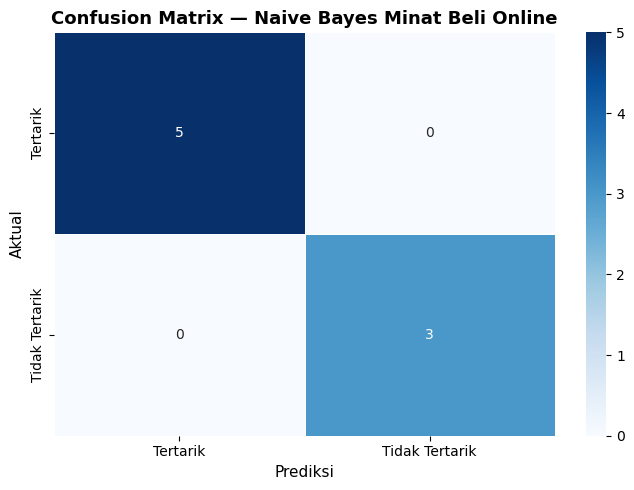


Keterangan:
  TP (True Positive)  = model benar memprediksi Tertarik
  TN (True Negative)  = model benar memprediksi Tidak Tertarik
  FP (False Positive) = model salah memprediksi Tertarik
  FN (False Negative) = model salah memprediksi Tidak Tertarik


In [7]:
# ============================================================
# Visualisasi Confusion Matrix
# ============================================================
cm = confusion_matrix(y_true_labels, y_pred_labels, labels=le_hasil.classes_)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_hasil.classes_,
    yticklabels=le_hasil.classes_,
    linewidths=0.5
)
plt.title('Confusion Matrix — Naive Bayes Minat Beli Online', fontsize=13, fontweight='bold')
plt.xlabel('Prediksi', fontsize=11)
plt.ylabel('Aktual', fontsize=11)
plt.tight_layout()
plt.show()
print("\nKeterangan:")
print("  TP (True Positive)  = model benar memprediksi Tertarik")
print("  TN (True Negative)  = model benar memprediksi Tidak Tertarik")
print("  FP (False Positive) = model salah memprediksi Tertarik")
print("  FN (False Negative) = model salah memprediksi Tidak Tertarik")

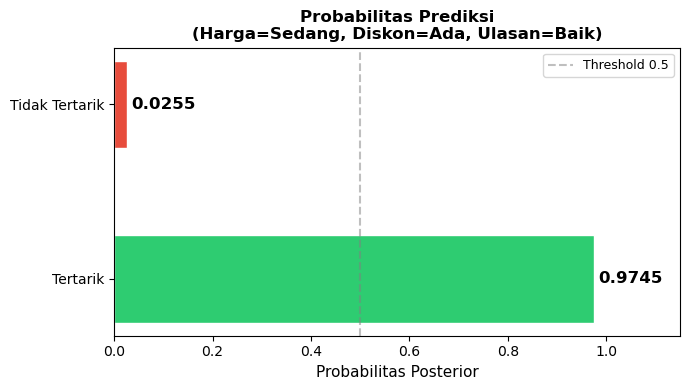


✅ Kesimpulan: Pelanggan diprediksi 'Tertarik' dengan probabilitas 0.9745


In [8]:
# ============================================================
# Visualisasi Probabilitas Prediksi Data Baru
# ============================================================
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2ecc71' if k == prediksi_label else '#e74c3c' for k in le_hasil.classes_]
bars = ax.barh(le_hasil.classes_, proba, color=colors, edgecolor='white', height=0.5)

for bar, prob in zip(bars, proba):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{prob:.4f}', va='center', fontsize=12, fontweight='bold')

ax.set_xlim(0, 1.15)
ax.set_xlabel('Probabilitas Posterior', fontsize=11)
ax.set_title(
    f'Probabilitas Prediksi\n(Harga=Sedang, Diskon=Ada, Ulasan=Baik)',
    fontsize=12, fontweight='bold'
)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold 0.5')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f"\n✅ Kesimpulan: Pelanggan diprediksi '{prediksi_label}' dengan probabilitas {max(proba):.4f}")

---
## 📌 Kesimpulan

### Hasil Klasifikasi:
Pelanggan dengan profil **Harga = Sedang, Diskon = Ada, Ulasan = Baik** diprediksi sebagai **✅ TERTARIK** membeli produk secara online.

### Alasan:
1. **Prior probability** kelas Tertarik lebih tinggi (5/8 = 0,625) dibanding Tidak Tertarik (3/8 = 0,375), artinya lebih banyak pelanggan yang tertarik dalam data latih.
2. **Likelihood** fitur-fitur data baru sangat mendukung kelas Tertarik — terutama Ulasan=Baik yang muncul di seluruh (100%) data bertipe Tertarik.
3. **Zero probability** muncul pada kelas Tidak Tertarik untuk fitur Harga=Sedang dan Ulasan=Baik. Masalah ini diatasi dengan **Laplace Smoothing** agar posterior tidak langsung menjadi 0.
4. **Nilai posterior** Tertarik jauh lebih besar, sehingga model memilih kelas Tertarik sebagai hasil prediksi akhir.

### Keterbatasan:
- Dataset sangat kecil (8 data), sehingga evaluasi model tidak bisa diandalkan sepenuhnya.
- Pada data nyata, perlu lebih banyak sampel dan teknik validasi seperti **cross-validation**.